In [19]:
cd ~/code/StinoNL/transfer_carrousel

/home/stijn/code/StinoNL/transfer_carrousel


/home/stijn/.pyenv/versions/transfer_carrousel/lib/python3.10/site-packages/IPython/core/magics/osm.py:393: UserWarning: This is now an optional IPython functionality, using bookmarks requires you to install the `pickleshare` library.
  bkms = self.shell.db.get('bookmarks', {})
/home/stijn/.pyenv/versions/transfer_carrousel/lib/python3.10/site-packages/IPython/core/magics/osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [20]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors
from IPython.display import HTML


In [21]:
# Load the dataset
df = pd.read_csv("complete_dataset/j_complete_dataset.csv")

# Show first rows
df.head()

,player_id,player_name,country_of_citizenship,foot,height_in_cm,season,first_game_date,last_game_date,club_id,club_name,domestic_competition_id,age,position,minutes_played,goals,assists,yellow_cards,red_cards,market_value_in_eur
0,10,Miroslav Klose,Germany,Right,184.0,12/13,2012-08-23,2013-06-30,398,Società Sportiva Lazio S.P.A.,IT1,35.0,Attack,2585,16,3,8,0,4000000.0
1,10,Miroslav Klose,Germany,Right,184.0,13/14,2013-08-18,2014-06-30,398,Società Sportiva Lazio S.P.A.,IT1,36.0,Attack,2220,8,5,2,0,1000000.0
2,10,Miroslav Klose,Germany,Right,184.0,14/15,2014-08-24,2015-06-30,398,Società Sportiva Lazio S.P.A.,IT1,37.0,Attack,2289,16,9,6,0,1000000.0
3,10,Miroslav Klose,Germany,Right,184.0,15/16,2015-08-08,2016-06-30,398,Società Sportiva Lazio S.P.A.,IT1,38.0,Attack,1714,8,8,3,0,1000000.0
4,26,Roman Weidenfeller,Germany,Left,190.0,12/13,2012-08-12,2013-06-30,16,Borussia Dortmund,L1,32.0,Goalkeeper,4401,0,0,2,1,4500000.0


In [22]:
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")

In [23]:
#just do one season just for ease
df_2324 = df[df["season"] == "23/24"].copy()

In [24]:
df_2324 = df_2324.dropna(subset=["market_value_in_eur"])

In [25]:
player_max_value = (
    df_2324.groupby(["player_id", "player_name"], as_index=False)["market_value_in_eur"]
    .max()
    .rename(columns={"market_value_in_eur": "max_market_value"})
)


In [26]:
# Step 5: Merge back features including team and league
performance_features = df_2324.drop_duplicates("player_id")[
    ["player_id","player_name", "age", "position", "minutes_played", "goals", "assists","yellow_cards", "red_cards",
     "club_name", "domestic_competition_id"]
]

df_clean = pd.merge(
    player_max_value.drop(columns="player_name"),  # Drop duplicate column
    performance_features,
    on="player_id",
    how="left"
)


In [27]:
df_images = pd.read_csv("clean_data/clean_players.csv")[["player_id", "image_url"]]

# Merge into df_clean
df_clean = df_clean.merge(df_images, on="player_id", how="left")

In [28]:
df_clean.head()

,player_id,max_market_value,player_name,age,position,minutes_played,goals,assists,yellow_cards,red_cards,club_name,domestic_competition_id,image_url
0,3333,1000000.0,James Milner,38.0,Midfield,955,0,2,3,0,Brighton And Hove Albion Football Club,GB1,https://img.a.transfermarkt.technology/portrai...
1,4391,62500.0,Boy Waterman,40.0,Goalkeeper,5,0,0,0,0,Eindhovense Voetbalvereniging Philips Sport Ve...,NL1,https://img.a.transfermarkt.technology/portrai...
2,5336,425000.0,Anastasios Tsokanis,33.0,Midfield,1693,0,0,7,0,Volou Neos Podosferikos Syllogos,GR1,https://img.a.transfermarkt.technology/portrai...
3,7161,11500000.0,Jonas Hofmann,31.0,Midfield,2768,8,12,4,0,Bayer 04 Leverkusen Fußball,L1,https://img.a.transfermarkt.technology/portrai...
4,7825,650000.0,Pepe Reina,41.0,Goalkeeper,1140,0,0,1,0,Villarreal Club De Fútbol S.A.D.,ES1,https://img.a.transfermarkt.technology/portrai...


In [29]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import pandas as pd

# Define position groups and features
position_groups = ["Attack", "Midfield", "Defender"]
features = ["age", "minutes_played", "goals", "assists", "max_market_value"]


In [30]:
# Create 'cluster' column fresh
df_clean["cluster"] = None

for group in position_groups:
    df_group = df_clean[df_clean["position"] == group].copy()
    X = df_group[features].dropna()
    player_ids_valid = df_group.loc[X.index, "player_id"].values

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    kmeans = KMeans(n_clusters=4, random_state=42)
    labels = kmeans.fit_predict(X_scaled)

    cluster_map = pd.DataFrame({
        "player_id": player_ids_valid,
        "cluster": [f"{group[:3]}_{label}" for label in labels]
    })

    # Merge clusters into df_clean
    df_clean = df_clean.merge(cluster_map, on="player_id", how="left", suffixes=("", "_new"))
    df_clean["cluster"] = df_clean["cluster"].combine_first(df_clean["cluster_new"])
    df_clean.drop(columns="cluster_new", inplace=True)


In [31]:
# Map clusters to fun football labels
cluster_name_mapping = {
    "Att_0": "Breakthrough Ballers",
    "Att_1": "Promising Prospects",
    "Att_2": "Elite Finishers",
    "Att_3": "Veteran Strikers",
    "Mid_0": "Midfield Apprentices",
    "Mid_1": "Reliable Engines",
    "Mid_2": "Aging Strategists",
    "Mid_3": "Creative Maestros",
    "Def_0": "Defensive Regulars",
    "Def_1": "Young Defenders",
    "Def_2": "Aging Backs",
    "Def_3": "Defensive Titans"
}

df_clean["cluster_name"] = df_clean["cluster"].map(cluster_name_mapping)


In [32]:
# Show average stats per cluster with readable names
features = ["age", "minutes_played", "goals", "assists", "max_market_value"]

cluster_summary = (
    df_clean
    .groupby(["cluster", "cluster_name"])[features]
    .mean()
    .round(2)
    .reset_index()
)

# Display the summary
import pandas as pd
cluster_summary.sort_values("cluster")  # Optional: to sort by cluster name


,cluster,cluster_name,age,minutes_played,goals,assists,max_market_value
0,Att_0,Breakthrough Ballers,26.20,2068.58,7.45,4.11,6975206.14
1,Att_1,Promising Prospects,21.49,372.02,0.98,0.50,2596620.37
2,Att_2,Elite Finishers,25.98,2959.26,16.93,8.39,45657638.89
3,Att_3,Veteran Strikers,29.34,739.29,1.94,0.97,2576125.56
4,Def_0,Defensive Regulars,30.45,1391.04,0.41,0.52,2071955.40
5,Def_1,Young Defenders,22.54,643.15,0.18,0.29,2303752.88
6,Def_2,Aging Backs,26.55,2499.36,1.84,2.51,5473380.91
7,Def_3,Defensive Titans,25.03,2804.98,2.30,2.40,40277891.16
8,Mid_0,Midfield Apprentices,21.81,512.00,0.42,0.45,2931155.60
9,Mid_1,Reliable Engines,26.35,2414.15,4.01,3.93,8872809.14


In [33]:
group = "Attack"
features = ["age", "minutes_played", "goals", "assists", "max_market_value"]

# Filter valid players in this position with cluster assigned
df_viz = df_clean[(df_clean["position"] == group) & (df_clean["cluster"].notna())]
X = df_viz[features].dropna()

# Scale
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [34]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)


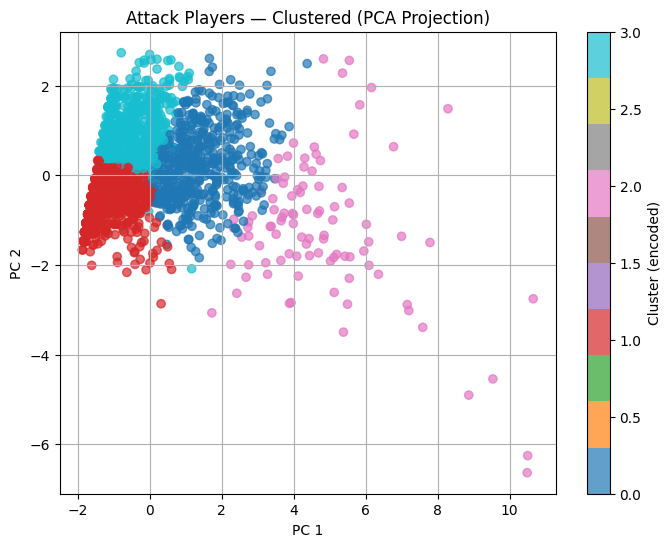

In [35]:
plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1],
            c=df_viz.loc[X.index, "cluster"].astype("category").cat.codes,
            cmap="tab10", alpha=0.7)

plt.title(f"{group} Players — Clustered (PCA Projection)")
plt.xlabel("PC 1")
plt.ylabel("PC 2")
plt.colorbar(label="Cluster (encoded)")
plt.grid(True)
plt.show()


In [36]:
target_name = "Kylian Mbappé"
target_player = df_clean[df_clean["player_name"].str.contains(target_name, case=False)].iloc[0]


In [37]:
target_cluster = target_player["cluster"]
cluster_players = df_clean[df_clean["cluster"] == target_cluster].copy()


In [38]:
features = ["age", "minutes_played", "goals", "assists", "max_market_value"]
X_cluster = cluster_players[features].dropna()

# Save who is who
cluster_players = cluster_players.loc[X_cluster.index].reset_index(drop=True)

# Scale
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)


In [39]:
from sklearn.neighbors import NearestNeighbors

knn = NearestNeighbors(n_neighbors=6, metric="euclidean")  # K=6 to include Mbappé + 5 others
knn.fit(X_scaled)

# Find the row of Mbappé
mbappe_vector = scaler.transform([target_player[features].values])
distances, indices = knn.kneighbors(mbappe_vector)


/home/stijn/.pyenv/versions/transfer_carrousel/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [40]:
# Get cheaper alternatives to target player
results = cluster_players.iloc[indices[0]]
cheaper_alternatives = results[results["max_market_value"] < target_player["max_market_value"]].copy()


In [41]:
from IPython.display import HTML

# Add image and cluster name to display_df
display_df = cheaper_alternatives[[
    "player_id", "player_name", "position", "max_market_value", "club_name", "image_url", "cluster"
]].copy()

display_df["market_value_million"] = (display_df["max_market_value"] / 1e6).round(2)
display_df["cluster_name"] = display_df["cluster"].map(cluster_name_mapping)

def render_images(df):
    df = df.copy()
    df["image"] = df["image_url"].apply(lambda url: f'<img src="{url}" width="50"/>')
    return HTML(df[["image", "cluster_name", "player_id", "player_name", "position", "market_value_million", "club_name"]]
                .to_html(escape=False))

render_images(display_df)


,image,cluster_name,player_id,player_name,position,market_value_million,club_name
57,,Elite Finishers,406625,Lautaro Martínez,Attack,106.67,Football Club Internazionale Milano S.P.A.
58,,Elite Finishers,406635,Phil Foden,Attack,130.00,Manchester City Football Club
11,,Elite Finishers,132098,Harry Kane,Attack,106.67,Fc Bayern München
63,,Elite Finishers,433177,Bukayo Saka,Attack,130.00,Arsenal Football Club
